# 🧱 이미지를 보고 벽돌깨기 플레이하기

<strong>최근 화면 2장 → AI의 위치·방향 인식 → AI의 행동 선택 → 게임 실행</strong>

실제 Atari `Breakout`을 OpenAI Decisions API로 조종합니다. 이미지 인식과 행동 결정을 <strong>별도 API 요청</strong>으로 나누어, 인식한 내용을 다음 요청에 직접 전달합니다. 숨겨진 공 좌표나 정답 행동은 사용하지 않습니다.

먼저 <strong>판단 한 번의 핵심 코드</strong>를 실행하고, 같은 흐름을 반복해 자동 플레이합니다. 마지막에는 <strong>인식 결과·리플레이·점수·응답 시간·달러/원화 비용</strong>을 확인합니다. 모델을 새로 훈련하는 강화학습은 아닙니다.

## 1. 준비

`부록`에서 `uv sync`를 실행하고, 노트북 커널은 `부록/.venv`의 Python을 선택합니다. 현재 폴더의 `.env`에 있는 `OPENAI_API_KEY`를 사용합니다.

게임은 설치된 `ale-py`의 Atari 환경을 사용합니다. 별도 실행 스크립트나 LangChain 래퍼 없이 이 노트북만 실행하면 됩니다.

In [1]:
import io
import json
import time
import base64
from pathlib import Path
from datetime import datetime
from collections import deque

import ale_py
import gymnasium as gym
import pandas as pd
from PIL import Image
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import display, HTML

# 현재 폴더의 키를 한 번만 읽습니다. SDK가 OPENAI_API_KEY를 사용합니다.
load_dotenv(".env")
client = OpenAI(timeout=30)  # 일시적인 서버 오류는 SDK 기본 재시도를 사용합니다.
gym.register_envs(ale_py)

SEED = 7
GAME_SECONDS = 10
HISTORY_SIZE = 2             # 직전 화면과 현재 화면을 비교합니다.
FRAMES_PER_ACTION = 3        # 과도한 이동을 줄이도록 0.05초씩 움직입니다.
USD_PER_MILLION_TOKENS = 0.10
KRW_PER_USD = 1500           # 실시간 환율이 아닌 가정값


## 2. 게임 화면 준비

아래 막대가 패들, 작은 빨간 점이 공입니다. 공을 놓치지 않고 위쪽 벽돌을 깨는 것이 목표입니다.

`frameskip=1`은 `step()` 한 번에 한 프레임씩 진행한다는 뜻입니다. `repeat_action_probability=0`으로 이전 행동이 확률적으로 반복되는 효과를 끕니다. <strong>공 발사(FIRE)는 시작 처리</strong>, 그 이후 패들 이동은 AI가 결정합니다.

게임 시점: 0.07초


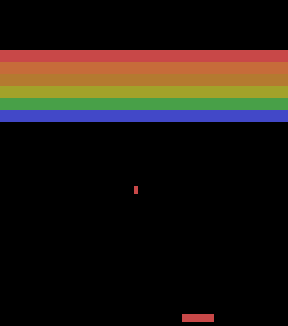

게임 시점: 0.12초


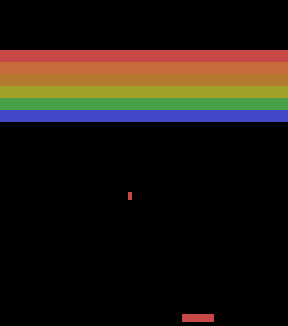

In [2]:
env = gym.make(
    "ALE/Breakout-v5", render_mode="rgb_array",
    frameskip=1, repeat_action_probability=0,
)
frame, info = env.reset(seed=SEED)
frame, _, _, _, _ = env.step(1)  # FIRE: 공 발사
history = deque(maxlen=HISTORY_SIZE)

# 핵심 호출 예제에서 움직임을 볼 수 있도록 0.05초 간격으로 장면을 모읍니다.
for index in range(HISTORY_SIZE):
    for _ in range(FRAMES_PER_ACTION):
        frame, _, _, _, _ = env.step(0)
    history.append((1 + (index + 1) * FRAMES_PER_ACTION, frame.copy()))

for frame_no, picture in history:
    print(f"게임 시점: {frame_no / 60:.2f}초")
    display(Image.fromarray(picture).crop((8, 32, 152, 195)).resize((288, 326), Image.Resampling.NEAREST))


## 3. 인식 → 행동 선택: 한 번의 핵심 실행

<strong>첫 번째 요청</strong>은 시간순 두 장에서 공의 상대 위치(`ball_side`), 가로 방향(`motion_x`), 세로 방향(`motion_y`)을 각각 분류합니다. 직전 패들 행동은 공의 방향과 혼동할 수 있어 이미지 설명에서 뺐습니다.

<strong>두 번째 요청</strong>은 첫 요청의 답을 실제 입력으로 받아 `left`·`right`·`stay`를 선택합니다. 한 요청 안의 독립 질문들이 앞선 답을 참고한다고 가정하지 않습니다. [공식 Decisions 문서](https://developers.openai.com/api/docs/guides/decisions)의 의존 질문 분리 방식입니다.

플레이 영역을 고정으로 잘라 <strong>576×652 PNG, `detail="high"`</strong>로 보냅니다. 원본 160×210 화면을 확대하는 것이므로 새로운 시각 정보가 생기는 것은 아닙니다. 좌표 추출·자동 조준은 하지 않으며, 공의 상대 위치와 이동 방향을 이용한 <strong>짧은 구간의 추적</strong>이지 정확한 벽 반사 궤적 계산은 아닙니다.

In [3]:
# 게임 숫자 명령: 0=대기, 1=공 발사, 2=오른쪽, 3=왼쪽
ACTIONS = {"stay": 0, "right": 2, "left": 3}
PERCEPTION_QUESTIONS = [
    {
        "type": "choice", "name": "ball_side",
        "instructions": (
            "In CURRENT only, where is the tiny isolated red ball relative to the "
            "red paddle at the bottom? Compare their horizontal positions, not heights. "
            "Ignore bricks and walls. Aligned means the ball is within the paddle's width."
        ),
        "choices": [{"value": v} for v in ["left", "aligned", "right", "unclear"]],
    },
    {
        "type": "choice", "name": "motion_x",
        "instructions": (
            "Track the tiny isolated red BALL from PREVIOUS to CURRENT. "
            "Does its screen x position decrease (left) or increase (right)? "
            "Track the ball, not the paddle. Choose unclear if the ball is not visible in both."
        ),
        "choices": [{"value": v} for v in ["left", "right", "unclear"]],
    },
    {
        "type": "choice", "name": "motion_y",
        "instructions": (
            "Track the tiny isolated red BALL from PREVIOUS to CURRENT. "
            "Does it move toward the top (up) or bottom (down)? "
            "Choose unclear if the ball is not visible in both."
        ),
        "choices": [{"value": v} for v in ["up", "down", "unclear"]],
    },
]
ACTION_QUESTION = {
    "type": "choice", "name": "paddle_action",
    "instructions": (
        "Choose a short paddle movement from the observed Breakout state. "
        "ball_side describes the BALL relative to the CURRENT paddle, not the reverse. "
        "If ball_side is left or right, move toward that side to get under the ball. "
        "If aligned and moving down, stay to receive it. "
        "If aligned and moving up, follow motion_x to prepare for its return. "
        "If the required observation is unclear, stay. Do not invent coordinates."
    ),
    "choices": [{"value": v} for v in ["left", "right", "stay"]],
}

def image_url(frame):
    # 고정 영역만 확대합니다. 공 좌표를 추출하거나 표시하지 않습니다.
    image = Image.fromarray(frame).crop((8, 32, 152, 195)).resize((576, 652), Image.Resampling.NEAREST)
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buffer.getvalue()).decode()

def sequence_content(history):
    # 이전 → 현재 순서와 실제 게임 시점을 명확하게 전달합니다.
    content = []
    for label, (frame_no, picture) in zip(["PREVIOUS", "CURRENT"], history):
        content.extend([
            {"type": "input_text", "text": f"{label}: game time {frame_no / 60:.3f}s"},
            {"type": "input_image", "image_url": image_url(picture), "detail": "high"},
        ])
    return content


### 화면을 보고 한 번 판단하기

아래가 핵심입니다. <strong>이미지를 보고 상태 인식 → 상태를 입력해 행동 선택</strong>으로 이어지는 API 2회 호출입니다. 시간 측정 없이 인식 결과와 행동만 확인하며, 아직 게임에는 적용하지 않습니다.

In [4]:
# 1차 요청: 두 화면에서 위치와 이동 방향을 읽습니다.
perception = client.decisions.create(
    model="gpt-6-luna",
    input=[{"role": "user", "content": sequence_content(history)}],
    questions=PERCEPTION_QUESTIONS,
)
state = {a.name: a.model_dump().get("choice", "unclear") for a in perception.answers}

# 2차 요청: 앞에서 인식한 내용을 실제 입력으로 전달합니다.
result = client.decisions.create(
    model="gpt-6-luna",
    input=json.dumps(state),
    questions=[ACTION_QUESTION],
)
print("인식 결과:", state)
print("선택 행동:", result.answers[0].model_dump().get("choice", "판단 거절"))


인식 결과: {'ball_side': 'left', 'motion_x': 'left', 'motion_y': 'up'}
선택 행동: left


## 4. 반복해서 사용할 판단 함수

3절의 두 요청을 함수로 묶습니다. 이미지 준비 시간은 제외하고 <strong>인식 요청 + 행동 요청</strong>의 시간을 합산합니다. 반환하는 입력 토큰 수도 두 요청의 합계입니다.

In [5]:
def decide(history):
    content = sequence_content(history)
    started = time.perf_counter()
    perception = client.decisions.create(
        model="gpt-6-luna",
        input=[{"role": "user", "content": content}],
        questions=PERCEPTION_QUESTIONS,
    )
    perception_seconds = time.perf_counter() - started
    state = {a.name: a.model_dump().get("choice", "unclear") for a in perception.answers}

    # 인식 결과를 다음 요청에 넘겨야 행동 판단이 그 답을 참고할 수 있습니다.
    started = time.perf_counter()
    result = client.decisions.create(
        model="gpt-6-luna", input=json.dumps(state), questions=[ACTION_QUESTION],
    )
    action_seconds = time.perf_counter() - started
    tokens = perception.usage.input_tokens + result.usage.input_tokens
    return state, result, perception_seconds + action_seconds, tokens


## 5. 10초 분량 자동 플레이

<strong>600프레임(60fps 기준 10초)</strong>을 진행하며, 3프레임마다 다시 판단합니다. 한 번 판단할 때 API를 두 번 호출하므로 최대 약 400회 요청합니다. 6프레임씩 움직였던 이전 코드보다 이동 단위를 줄였습니다.

공을 잃으면 목숨 수를 보고 FIRE로 다시 발사합니다. 발사만 자동 처리하고 `serve`·비용 0으로 기록합니다. 패들 이동은 두 번째 API의 답을 그대로 적용하며 코드에서 방향을 덮어쓰지 않습니다.

API 대기 중에는 게임이 정지합니다. 실제 실행 시간은 게임 시간보다 길며, 목숨이 모두 없어지거나 행동 판단이 거절되면 일찍 멈춥니다. 재실행하면 다시 과금됩니다.

`deque(maxlen=2)`에는 직전·현재 장면만 남습니다. 새 공을 발사할 때 기록을 비워 이전 공의 궤적과 섞이지 않게 합니다. 프레임 간격은 `FRAMES_PER_ACTION / 60`초입니다.

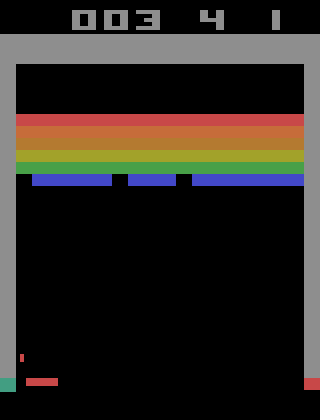

001 | serve | 점수 0 | 0.000초 | $0.000000


002 | left  | 점수 0 | 0.466초 | $0.000143


003 | left  | 점수 0 | 0.448초 | $0.000143


004 | left  | 점수 0 | 0.615초 | $0.000143


005 | left  | 점수 0 | 0.462초 | $0.000143


...

196 | left  | 점수 3 | 0.458초 | $0.000143


197 | left  | 점수 3 | 0.487초 | $0.000143


198 | left  | 점수 3 | 0.469초 | $0.000143


199 | right | 점수 3 | 0.467초 | $0.000143


200 | left  | 점수 3 | 0.492초 | $0.000143


In [6]:
# 한 번 판단한 예제와 분리해 게임을 처음부터 다시 시작합니다.
frame, info = env.reset(seed=SEED)
history = deque([(0, frame.copy())], maxlen=HISTORY_SIZE)
lives, serve = info["lives"], True
frames, rows = [], []
score, frame_count = 0, 0
stop_reason = "time_limit"
screen = display(Image.fromarray(frame), display_id=True)
started = time.perf_counter()

for turn in range(GAME_SECONDS * 60 // FRAMES_PER_ACTION):
    if serve:
        # 새 공이므로 이전 공의 이동 기록을 보내지 않습니다.
        history.clear()
        history.append((frame_count, frame.copy()))
        action, seconds, tokens = "serve", 0.0, 0  # 공 발사만 자동 처리
        state = {}
    else:
        # 이미지 인식과 행동 판단을 순서대로 호출합니다.
        state, result, seconds, tokens = decide(history)
        answer = result.answers[0].model_dump()
        action = answer.get("choice", "refused")

    usd = tokens / 1_000_000 * USD_PER_MILLION_TOKENS
    rows.append({**state, "행동": action, "판단 시간(초)": seconds, "입력 토큰": tokens,
                 "비용($)": usd, "비용(원)": usd * KRW_PER_USD,
                 "입력 시점(초)": [round(t / 60, 3) for t, _ in history],
                 "confidence": answer.get("confidence") if not serve else None})
    if action == "refused":
        stop_reason = "refused"
        break

    # AI가 선택한 방향으로 실제 게임을 진행하고 점수·화면을 기록합니다.
    for _ in range(FRAMES_PER_ACTION):
        frame, reward, terminated, truncated, info = env.step(1 if serve else ACTIONS[action])
        score += reward
        frame_count += 1
        if frame_count % 3 == 0:  # 3프레임마다 저장 → 20fps 리플레이
            frames.append(Image.fromarray(frame))
        if terminated or truncated:
            break

    # 새 장면을 추가하면 가장 오래된 장면은 자동으로 빠집니다.
    history.append((frame_count, frame.copy()))
    # 목숨이 줄면 다음 차례에 다시 발사합니다. 이동 방향은 덮어쓰지 않습니다.
    serve = info["lives"] < lives
    lives = info["lives"]
    if screen is not None:
        screen.update(Image.fromarray(frame).resize((320, 420), Image.Resampling.NEAREST))
    print(f"{turn + 1:03d} | {action:5s} | 점수 {score:.0f} | {seconds:.3f}초 | ${usd:.6f}", flush=True)
    if terminated or truncated:
        stop_reason = "game_over"
        break

wall_seconds = time.perf_counter() - started
env.close()


## 6. 결과·시간·비용

표에서 `ball_side`(공의 상대 위치), `motion_x`(가로 이동), `motion_y`(세로 이동)와 <strong>행동</strong>을 나란히 비교합니다. 인식이 잘못됐는지, 인식 결과와 행동이 어긋났는지 구분할 수 있습니다. `confidence`는 행동 답의 값이며 정답 보장은 아닙니다.

<strong>판단 시간</strong>은 두 요청의 합계이고, <strong>API 1회 평균</strong>은 전체 요청 시간 ÷ 실제 요청 수입니다. 로컬 공 발사는 제외합니다. 아래 비용은 <strong>5절 자동 플레이만</strong> 포함하며 3절 예제의 두 요청은 별도 과금됩니다.

기본 요금은 입력 100만 토큰당 $0.10, 환율은 1달러=1,500원 가정입니다. 지역 처리 할증·세금은 제외한 추정치입니다. 단일 실행 점수는 일반적인 모델 성능을 보장하지 않습니다.

In [7]:
# 인식한 내용 바로 옆에서 선택 행동을 비교합니다.
report = pd.DataFrame(rows).reindex(columns=[
    "ball_side", "motion_x", "motion_y", "행동", "confidence",
    "판단 시간(초)", "입력 토큰", "비용($)", "비용(원)", "입력 시점(초)",
])
# 한 번의 판단은 인식 요청 1회 + 행동 요청 1회입니다.
api_rows = report[report["행동"] != "serve"]
api_calls = len(api_rows) * 2
average_api_seconds = api_rows["판단 시간(초)"].sum() / api_calls
display(report.style.format({
    "판단 시간(초)": "{:.3f}", "비용($)": "${:.6f}", "비용(원)": "₩{:.3f}",
}))
print(f"점수: {score:.0f} / 남은 목숨: {lives} / 종료: {stop_reason}")
print(f"게임: {frame_count / 60:.2f}초 / 실제 실행: {wall_seconds:.2f}초")
print(f"판단 {len(api_rows)}회 / 평균 판단: {api_rows['판단 시간(초)'].mean():.3f}초")
print(f"API {api_calls}회 / 요청 1회 평균: {average_api_seconds:.3f}초")
print(f"자동 플레이 비용: ${report['비용($)'].sum():.6f} / ₩{report['비용(원)'].sum():.3f}")


,ball_side,motion_x,motion_y,행동,confidence,판단 시간(초),입력 토큰,비용($),비용(원),입력 시점(초)
0,nan,nan,nan,serve,nan,0.000,0,$0.000000,₩0.000,[0.0]
1,left,left,up,left,0.960000,0.466,1426,$0.000143,₩0.214,"[0.0, 0.05]"
2,left,left,up,left,0.960000,0.448,1426,$0.000143,₩0.214,"[0.05, 0.1]"
3,left,left,up,left,0.960000,0.615,1426,$0.000143,₩0.214,"[0.1, 0.15]"
4,left,left,up,left,0.960000,0.462,1426,$0.000143,₩0.214,"[0.15, 0.2]"
5,left,left,down,left,0.960000,0.465,1426,$0.000143,₩0.214,"[0.2, 0.25]"
6,left,left,up,left,0.960000,0.454,1426,$0.000143,₩0.214,"[0.25, 0.3]"
7,right,left,up,right,0.970000,0.439,1426,$0.000143,₩0.214,"[0.3, 0.35]"
8,right,right,down,right,0.970000,0.462,1426,$0.000143,₩0.214,"[0.35, 0.4]"
9,right,left,down,right,0.330000,0.514,1426,$0.000143,₩0.214,"[0.4, 0.45]"


점수: 3 / 남은 목숨: 4 / 종료: time_limit
게임: 10.00초 / 실제 실행: 103.53초
판단 198회 / 평균 판단: 0.498초
API 396회 / 요청 1회 평균: 0.249초
자동 플레이 비용: $0.028237 / ₩42.355


## 7. 실제 플레이 리플레이

기록한 실제 게임 화면을 <strong>20fps GIF</strong>로 저장하고 바로 재생합니다. 600프레임까지 진행했다면 약 10초이고, 조기 종료되었다면 더 짧습니다. API 대기 시간을 늘려 붙이지 않습니다.

실행마다 새 폴더에 GIF·HTML·행동/비용 CSV·실행 요약을 저장합니다. HTML 파일은 브라우저에서 단독으로 열 수 있습니다.


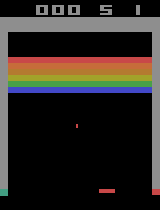

리플레이: output\breakout\20261008_165159_470501\replay.html


In [8]:
run_dir = Path("output/breakout") / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
run_dir.mkdir(parents=True)
gif_path = run_dir / "play.gif"
# 저장된 화면 한 장을 50ms씩 보여주면 초당 20장입니다.
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=50, loop=0)
report.to_csv(run_dir / "actions.csv", index=False, encoding="utf-8-sig")

summary = {"policy": "perception_then_action", "image_detail": "high", "history_size": HISTORY_SIZE, "seed": SEED, "frames_per_action": FRAMES_PER_ACTION,
           "score": score, "lives": lives, "stop_reason": stop_reason,
           "game_seconds": frame_count / 60, "wall_seconds": wall_seconds,
           "replay_seconds": len(frames) / 20, "api_calls": api_calls,
           "average_api_seconds": average_api_seconds,
           "cost_usd": report["비용($)"].sum(), "cost_krw": report["비용(원)"].sum()}
(run_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
# HTML 안에 GIF를 넣어 별도 파일 경로 없이 재생할 수 있게 합니다.
gif64 = base64.b64encode(gif_path.read_bytes()).decode()
replay = f'<img src="data:image/gif;base64,{gif64}" width="480" style="image-rendering:pixelated">'
(run_dir / "replay.html").write_text('<meta charset="utf-8"><title>AI Breakout</title>' + replay, encoding="utf-8")
display(HTML(replay))
print("리플레이:", run_dir / "replay.html")


### 읽어볼 점

화면을 고해상도 모드로 보내더라도 작은 공의 위치·방향을 잘못 읽을 수 있습니다. 두 단계 구조는 이런 오류를 <strong>확인하기 쉽게</strong> 만들지만 정확도 향상을 보장하지 않습니다. 행동 프롬프트도 완전한 물리 시뮬레이터가 아닌 짧은 구간 추적 전략입니다.

`FRAMES_PER_ACTION`을 줄이면 더 자주 판단하지만 이동 차이가 작아져 방향 인식이 어려울 수 있습니다. 늘리면 요청 비용은 줄지만 패들이 목표를 지나칠 수 있습니다.

<strong>출처:</strong> [Breakout 환경·행동](https://ale.farama.org/environments/breakout/) · [Decisions API·독립/의존 질문·기본 요금](https://developers.openai.com/api/docs/guides/decisions)

게임 자산은 설치된 ALE 패키지에서 읽으며 ROM 파일을 별도로 배포하지 않습니다.
